# Bias in Machine Learning Workbook


This is a workbook designed to mimic the Amazon AI Hiring scandal from 2018. We will assume that we are fictious company attempting to build a model that will automatically screen resumes for applicants that would fit best in our company. We have a labeled dataset containing resumes from past applicant pools labeled with whether an applicant was hired. The goal of this notebook is to investigate this data and build an unbiased (hopefully!) model to filter resumes and find the best candidates. This notebook requires a labeled dataset containing examples of resumes that have been hired or rejected in the past, this dataset should be provided.



## 0. Define Visualization Functions


In [1]:
def viewDataDistributions(data, category):

  categorical_columns = data.select_dtypes(exclude=['number']).columns

  if category not in data.columns:
      print(f"Warning: '{category}' is not a valid category in the Data.")
      return

  elif category in categorical_columns:
      plt.figure()
      sns.histplot(data=data, x=category, hue='Sex', stat='probability',
                   multiple='dodge', common_norm=False, shrink=0.8,
                   palette="viridis")
      plt.title(f'Distribution of {category}')
      plt.xlabel(category)
      plt.ylabel('Normalized Count')
      plt.xticks(rotation=45)
  else:
      # Sex distribution for circle chart
      sex_counts = data[category].value_counts()

      # Overlayed category distribution by sex
      plt.figure()
      sns.histplot(data, x=category, hue='Sex', kde=True, bins=10, palette=['#66c2a5', '#fc8d62'],
                  element='step', stat='probability', common_norm=False, alpha=0.6)
      plt.title(f'{category} Distribution by Sex')
      plt.xlabel(category)
      plt.ylabel('Normalized Frequency')

      # Add text boxes with the average for each sex
      average_by_sex = data.groupby('Sex')[category].mean()
      for i, sex in enumerate(average_by_sex.index):
          avg = average_by_sex[sex]
          plt.text(0.1, 0.9 - i * 0.1,
                  f'Average {category} ({sex}): {avg:.2f}',
                  color='#66c2a5' if sex == 'Male' else '#fc8d62', fontsize=10,
                  weight='bold', bbox=dict(facecolor='white', edgecolor='black',
                                            boxstyle='round,pad=0.3'),
                  transform=plt.gca().transAxes)

      plt.show()

In [2]:
def viewSexDistribution(data):
  sex_counts = data['Sex'].value_counts()
  plt.figure()
  plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
  plt.title('Sex Distribution')

  plt.tight_layout()
  plt.show()

In [3]:
def plotFeatureImportance(model, X_usedToTrain):
    # Get feature importances from the Random Forest model
    importances = model.feature_importances_
    feature_names = X_usedToTrain.columns

    # Create a DataFrame to hold feature names and their importance scores
    feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

    # Sort the DataFrame by importance
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Plot feature importances
    plt.figure()
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Feature Importance from Random Forest Model")
    plt.gca().invert_yaxis()  # Invert y-axis to show the most important features on top
    plt.show()

In [4]:
def getTopApplicants(model, X_test, featuresToDrop=None, fairModel=False):
    if featuresToDrop is not None:
        X_test_dum = pd.get_dummies(X_test.drop(columns=featuresToDrop), drop_first=True)
    else:
        X_test_dum = pd.get_dummies(X_test, drop_first=True)

    if fairModel:
      applicant_probabilities = model._pmf_predict(np.array(X_test_dum))[:, 1]  # Probabilities for "Hired" class
    else:
      applicant_probabilities = model.predict_proba(np.array(X_test_dum))[:, 1]  # Probabilities for "Hired" class

    # Add predictions to the Applicant dataset and rank applicants by probability
    X_copy = X_test.copy()
    X_copy['Predicted_Probability_Hired'] = applicant_probabilities
    top_candidates = X_copy.sort_values(by='Predicted_Probability_Hired', ascending=False).head(50)

    return top_candidates

### Import Libraries

In [5]:
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from sklearn.metrics import confusion_matrix, accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate

## 1. Import and Visualize Data

To import these you will need to grab the csv's from Canvas and upload them to the colab sample_data folder manually or save them on your drive somewhere and mount your drive similar to how you've done it in the homeworks.

In [7]:
# Import csv files as pandas data frame
# Replace with path to your data!
resumeData = pd.read_csv('../dataset/EmployedResumes.csv')

Let's look at some of the employed resume data.

In [8]:
resumeData.head(10)

,Applicant_ID,Sex,Employment_Gaps,College_Club,Resume_Keywords,Education_Level,Years_Experience,Skills,Position_Level,Certifications,Programming_Languages,Project_Count,GPA,Hired
0,415,Male,0,Coding Society,achieved,Master's,8.0,system architecture,Mid,Google Analytics Certified,Python,4.0,3.35,1
1,606,Male,0,Coding Society,achieved,Bachelor's,9.0,software engineering,Entry,Certified Scrum Master,C++,8.0,3.09,1
2,750,Male,0,Tech Club,innovated,Master's,3.0,data analysis,Senior,Certified Scrum Master,Java,7.0,3.15,0
3,744,Male,0,Tech Club,strategic,Bachelor's,7.0,customer service,Entry,Certified Scrum Master,Java,5.0,3.95,1
4,926,Female,0,Tech Club,organized,Bachelor's,0.0,system architecture,Entry,Google Analytics Certified,Python,4.0,3.83,0
5,641,Male,0,Coding Society,led,Bachelor's,4.0,software engineering,Entry,Certified Scrum Master,JavaScript,11.0,3.40,0
6,560,Male,0,Student Council,achieved,Bachelor's,14.0,system architecture,Mid,Certified Scrum Master,NaN,0.0,4.00,1
7,174,Male,0,Fraternity,support,Bachelor's,2.0,machine learning,Mid,Google Analytics Certified,Python,3.0,2.83,0
8,820,Female,0,Women in Tech,collaborative,Bachelor's,9.0,customer service,Mid,AWS Certified,Java,9.0,3.53,1
9,303,Male,0,Tech Club,achieved,Master's,12.0,project management,Entry,PMP,Java,3.0,2.25,1


Let's view the overall percentage of females and males in the data.

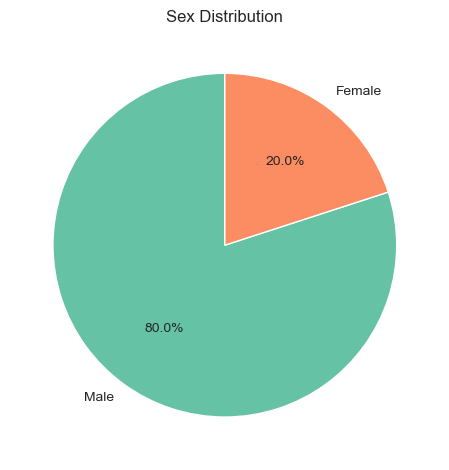

In [10]:
viewSexDistribution(resumeData)

We can now visualize the distribution of males and females for each category within the resume. Note that the plot will change for numeric values and categorical. Feel free to put in any column name as an input.

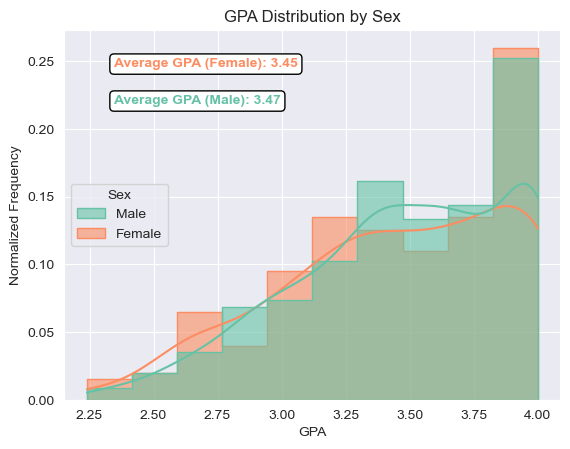

In [11]:
viewDataDistributions(resumeData, 'GPA')

## 2. Create a Model to Hire the Top 50 Applicants

We first will need to train a model using the best practices we've learned in class to predict wether or not a person would be hired based on previous hires (those labeled as such in the dataset).

Once we have trained a model we can rank them based on the probability they'll be hired and then choose the top 50 of our test set to hire.

In [12]:
features = resumeData.drop(columns=['Applicant_ID', 'Hired'])
targets = resumeData['Hired']

X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.3, random_state=42)

X_train_dum = pd.get_dummies(X_train, drop_first=True)
# Define classifiers for grid search
classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

# Define hyperparameters for each model
param_grid = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]},
    'Decision Tree': {'max_depth': [5, 10, None]}
}

# Grid search to find the best model
best_models = {}
for clf_name, clf in classifiers.items():
    grid_search = GridSearchCV(clf, param_grid[clf_name], cv=5, scoring='accuracy')
    grid_search.fit(np.array(X_train_dum), np.array(y_train))
    best_models[clf_name] = grid_search.best_estimator_
    print(f"Best parameters for {clf_name}: {grid_search.best_params_}")

# Evaluate the best model (choosing Random Forest for this example)
best_model = best_models['Random Forest']


/Users/annikalindstrom/opt/anaconda3/envs/BiasWorkshop/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/annikalindstrom/opt/anaconda3/envs/BiasWorkshop/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https

Best parameters for Logistic Regression: {'C': 10}
Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 100}
Best parameters for Decision Tree: {'max_depth': 5}


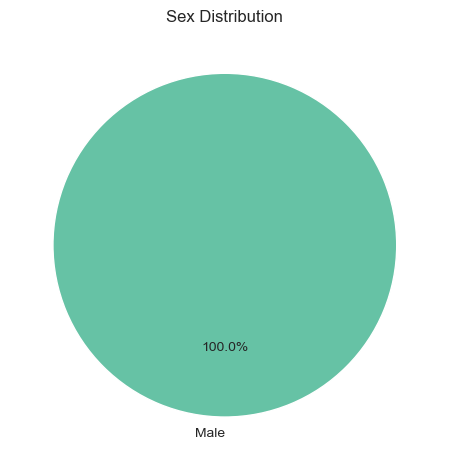

In [13]:
top_candidates = getTopApplicants(best_model, X_test)

viewSexDistribution(top_candidates)

/var/folders/j6/m5mnf5691xx3dd_c2q644qk40000gn/T/ipykernel_18697/3913129694.py:24: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.histplot(data, x=category, hue='Sex', kde=True, bins=10, palette=['#66c2a5', '#fc8d62'],


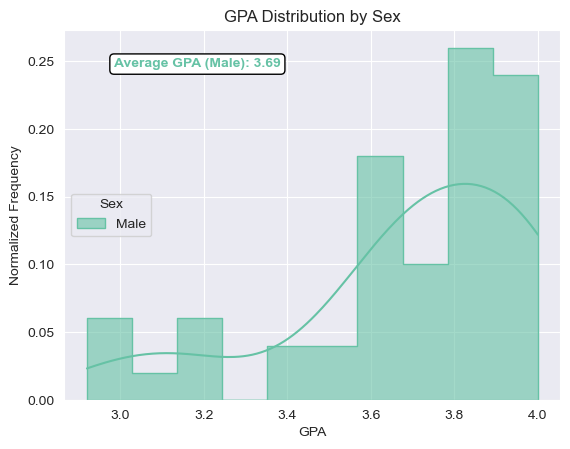

In [14]:
viewDataDistributions(top_candidates, 'GPA')

## 3. Try to Make Your Model Better!

First try excluding features you think could be causing the bias, gender is the obvious choice, but are there others?

Compute the correlation between gender and other features and then remove the features that are highly correlated with gender.

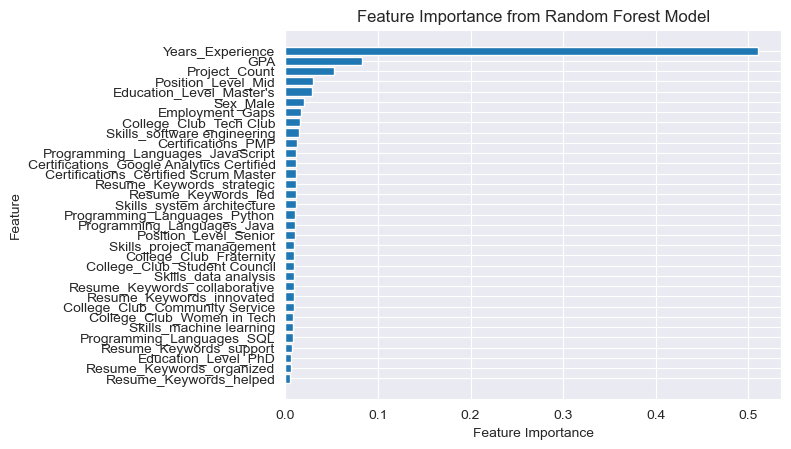

In [15]:
plotFeatureImportance(best_model, X_train_dum)

### Calculate Feature Correlations

In [16]:
# Extract sensitive attributes and features for correlation analysis
sensitive_attributes = ['Sex']  # Replace with the actual sensitive attributes in your dataset
features = [col for col in resumeData.columns if col not in ['Applicant_ID', 'Hired'] + sensitive_attributes]

# Encode sensitive attributes and categorical features
sensitive_encoded = pd.get_dummies(resumeData[sensitive_attributes], drop_first=True)

numeric_features = pd.DataFrame()
for feature in features:
    if resumeData[feature].dtype == 'object':  # Check if the column is categorical
        # One-hot encode categorical features
        encoded = pd.get_dummies(resumeData[feature], prefix=feature, drop_first=True)
        numeric_features = pd.concat([numeric_features, encoded], axis=1)
    else:
        # If already numeric, add directly
        numeric_features[feature] = resumeData[feature]

# Combine sensitive attributes and features
combined_data = pd.concat([sensitive_encoded, numeric_features], axis=1)

# Compute the correlation matrix
correlation_matrix = combined_data.corr()

# Extract correlations of sensitive attributes with other features
sensitive_encoded_cols = sensitive_encoded.columns
correlation_with_sensitive = correlation_matrix.loc[sensitive_encoded_cols, numeric_features.columns]

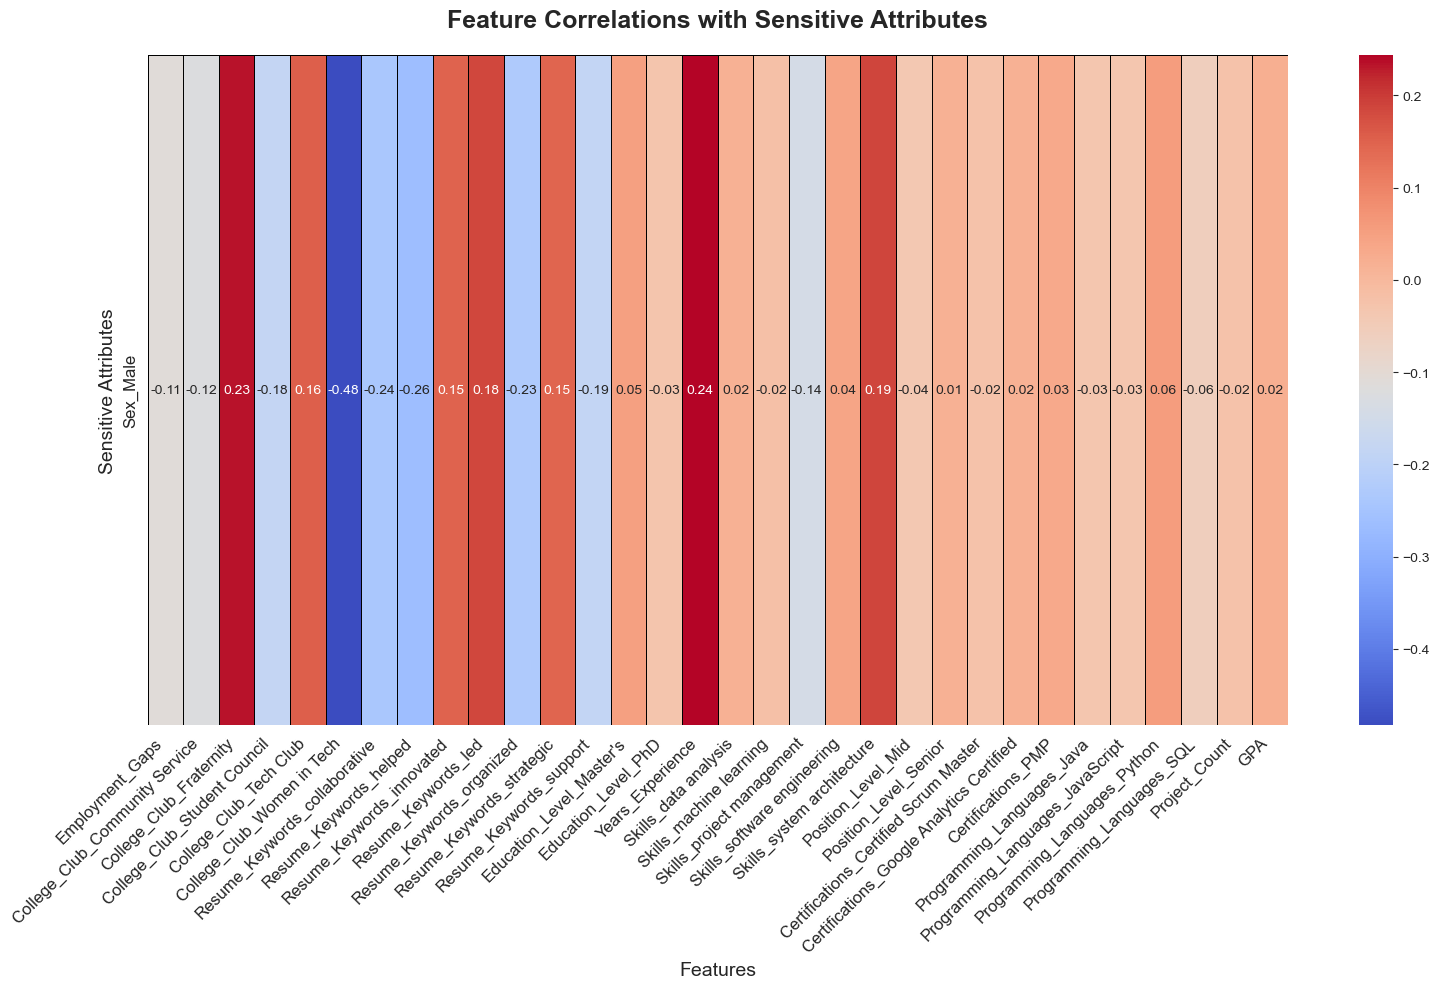

In [17]:
# Enhanced heatmap visualization
plt.figure(figsize=(16, 10))

# Create a heatmap with better spacing and font adjustments
sns.heatmap(
    correlation_with_sensitive,
    annot=True,          # Display the correlation values
    fmt=".2f",           # Format the values with 2 decimal points
    cmap="coolwarm",     # Color scheme
    cbar=True,           # Show the color bar
    linewidths=0.5,      # Add grid lines for better readability
    linecolor='black',   # Grid line color
    annot_kws={"size": 10}  # Annotation font size
)

# Add titles and labels with improved font sizes
plt.title("Feature Correlations with Sensitive Attributes", fontsize=18, weight='bold', pad=20)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Sensitive Attributes", fontsize=14)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add tight layout to prevent label overlap
plt.tight_layout()

# Show the plot
plt.show()

In [18]:
# Drop certain features and train a new model here!
featuresToDrop = ['Sex', 'College_Club', 'Years_Experience']
X_train_dropped = X_train.drop(columns=featuresToDrop)
X_train_dropped_dum = pd.get_dummies(X_train_dropped, drop_first=True)

model = RandomForestClassifier()
model.fit(X_train_dropped_dum, y_train)

topApplicants_dropped = getTopApplicants(model, X_test, featuresToDrop)

/Users/annikalindstrom/opt/anaconda3/envs/BiasWorkshop/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


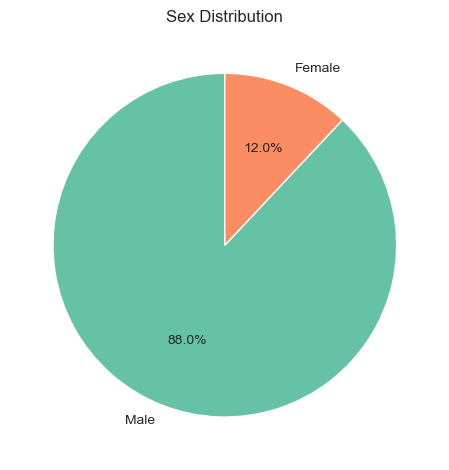

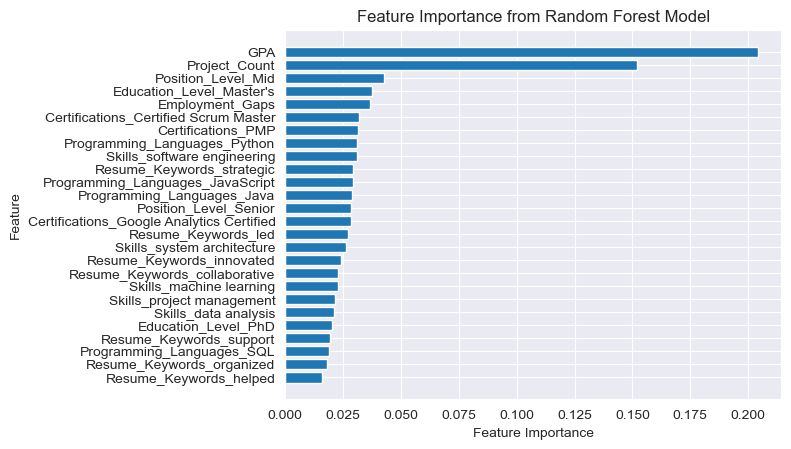

In [19]:
# View Resuls Here
viewSexDistribution(topApplicants_dropped)

plotFeatureImportance(model, X_train_dropped_dum)

You may have been able to reduce bias using this technique, but did you loose any predictive power?

Next you could try over/under sampling the original data to see if we can remove bias by artificially balancing the training data.

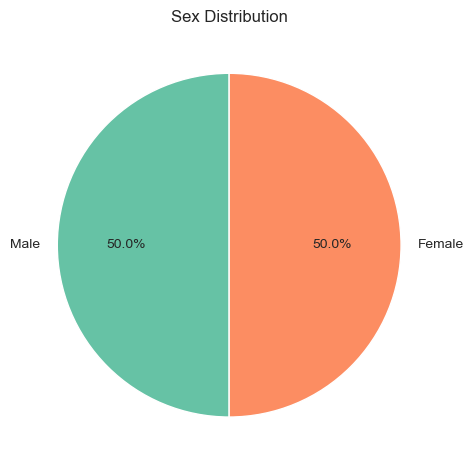

In [20]:
# Separate males and females
male_data = resumeData[resumeData['Sex'] == 'Male']
female_data = resumeData[resumeData['Sex'] == 'Female']

# Undersample males to match the number of females
male_data_undersampled = male_data.sample(len(female_data), random_state=42)
balanced_data_undersample = pd.concat([male_data_undersampled, female_data], axis=0)

viewSexDistribution(balanced_data_undersample)

In [21]:
# Train model with balanced data
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(balanced_data_undersample.drop(columns=['Hired']),
                                                                    balanced_data_undersample['Hired'], test_size=0.3,
                                                                    random_state=42)

X_train_bal_dum = pd.get_dummies(X_train_bal, drop_first=True)
model = RandomForestClassifier()
model.fit(X_train_bal_dum, y_train_bal)

topApplicants_balanced = getTopApplicants(model, X_test_bal)

/Users/annikalindstrom/opt/anaconda3/envs/BiasWorkshop/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


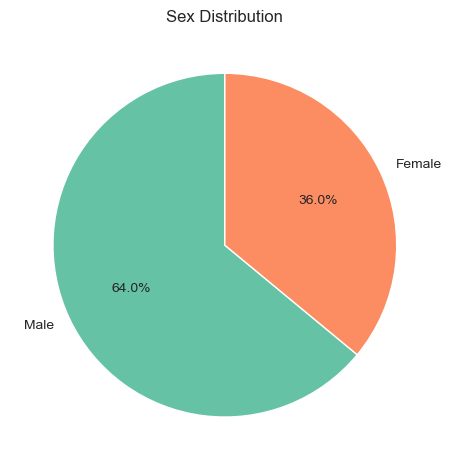

In [22]:
# Visualize your results here!
viewSexDistribution(topApplicants_balanced)

### Using Fairlearn

Try using an open source library, fairlearn to mitigate any bias present.

In [23]:
# Define the sensitive feature (e.g., Sex) and target
sensitive_feature = X_train_dum['Sex_Male'] if 'Sex_Male' in X_train_dum.columns else 0

# Set up the model and fairness constraint
base_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
constraint = DemographicParity()  # or use EqualizedOdds() for an alternative fairness constraint

# Apply ExponentiatedGradient to enforce the fairness constraint during training
mitigated_model = ExponentiatedGradient(base_model, constraints=constraint)
mitigated_model.fit(X_train_dum, y_train, sensitive_features=sensitive_feature)

X_test_dum = pd.get_dummies(X_test, drop_first=True)
y_pred_mitigated = mitigated_model.predict(X_test_dum)

In [25]:
# Evaluate the mitigated model's accuracy and fairness
overall_accuracy_mitigated = accuracy_score(y_test, y_pred_mitigated)
print("Mitigated Model Accuracy:", overall_accuracy_mitigated)

# Evaluate fairness
metric_frame_mitigated = MetricFrame(
    metrics={'accuracy': accuracy_score, 'selection_rate': selection_rate},
    y_true=y_test,
    y_pred=y_pred_mitigated,
    sensitive_features=X_test_dum['Sex_Male']
)

print("Mitigated Accuracy by Sex:\n", metric_frame_mitigated.by_group['accuracy'])
print("Mitigated Selection Rate by Sex:\n", metric_frame_mitigated.by_group['selection_rate'])


Mitigated Model Accuracy: 0.8733333333333333
Mitigated Accuracy by Sex:
 Sex_Male
False    0.704918
True     0.916318
Name: accuracy, dtype: float64
Mitigated Selection Rate by Sex:
 Sex_Male
False    0.491803
True     0.539749
Name: selection_rate, dtype: float64


In [26]:
# Evaluate TPR and FPR for each sex
def true_positive_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[1, 1] / (cm[1, 1] + cm[1, 0])

def false_positive_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm[0, 1] / (cm[0, 1] + cm[0, 0])

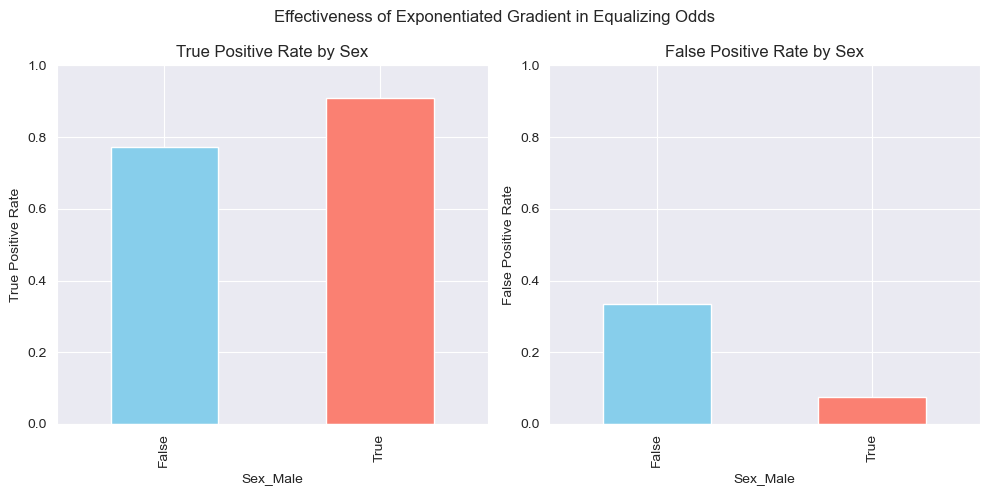

In [27]:
# Use MetricFrame to compute TPR and FPR for each gender group
metric_frame = MetricFrame(
    metrics={'TPR': true_positive_rate, 'FPR': false_positive_rate},
    y_true=y_test,
    y_pred=y_pred_mitigated,
    sensitive_features=X_test_dum['Sex_Male']
)

# Extract TPR and FPR for each group
tpr_values = metric_frame.by_group['TPR']
fpr_values = metric_frame.by_group['FPR']

# Plot TPR and FPR to visualize Equalized Odds
import matplotlib.pyplot as plt

# TPR plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
tpr_values.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("True Positive Rate by Sex")
plt.ylabel("True Positive Rate")
plt.ylim(0, 1)

# FPR plot
plt.subplot(1, 2, 2)
fpr_values.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("False Positive Rate by Sex")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)

plt.suptitle("Effectiveness of Exponentiated Gradient in Equalizing Odds")
plt.tight_layout()
plt.show()